<a href="https://colab.research.google.com/github/benplic/quantum-computing-learning/blob/main/notebooks/quantum_phase_estimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantum Phase Estimation: Precision Scaling, Binary Grid Rounding, and Spectral Leakage

## 1. Mathematical Premise & Problem Formulation

**The Beginning**

In order to understand phase estimation I first had to understand Spectral Theorem because the two are related in a fascinating way. While there is more to it, the most important implication of spectral theorem is this:

> Given a unitary operator $U$ on an $N$ dimensional Hilbert space, there exists some orthonormal basis $\{\vert \psi _1\rangle…\vert\psi_N\rangle\}$ of vectors along with complex numbers $\lambda_1=e^{2πi\theta_1} \dots \lambda_N=e^{2πiθ_N}$ such that $U=∑_{k=1}^N λ_k\vert \psi_k \rangle \langle \psi_k \vert$

This is the spectral decomposition, and this shows that each vector $\vert\psi_k\rangle$ is an eigenvector of $U$ with an eigenvalue of $\lambda_k$. That is to say, $$U\vert \psi_k \rangle = e^{2πi\theta_k}\vert \psi_k \rangle$$



**The Phase Estimation Problem**

Given a description of a quantum circuit, $U$, on n qubits and an n-qubit quantum state $\vert\psi\rangle$, and knowing that $\vert\psi\rangle$ is an eigenvalue of $U$, approximate the number $θ \in [0,1)$ satisfying $U\vert\psi\rangle = e^{2πi\theta}\vert\psi\rangle$.

Since standard phases range over $θ \in [0,1)$, adding in $\theta$ allows for a binary fraction output by a program to estimate a specific phase.

$$\theta = 0.\theta_1 \theta_2 \theta_3 …= \sum_{k=1}^{\infty} \theta_k 2^{-k}, \quad \theta_k \in \{0, 1\}$$

## 2. Circuit Synthesis & Execution

In [1]:
!uv pip install qiskit qiskit-aer

Using Python 3.13.15 environment at: /usr
Checked 2 packages in 175ms


In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import QFTGate
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
import numpy as np
import matplotlib.pyplot as plt
import time

def bitstring_to_phase(bitstring: str, t:int) -> float:
  decimal = int(bitstring, 2)
  return decimal/(2**t)

In [3]:
#Set counting register size
t = 4
#Set test phase
theta = 0.37

shots = 8192
#create circuit
def build_qpe_circuit(t: int, theta: float) -> QuantumCircuit:
  counting = QuantumRegister(t,"c")
  target = QuantumRegister(1,"t")
  measure = ClassicalRegister(t,"m")
  qc = QuantumCircuit(counting,target,measure)

  #step 1: intitialize circuit
  for qubit in counting:
    qc.h(qubit)

  for qubit in target:
    qc.x(qubit)

  #step 2: phase kickback
  for j in range(t):
    #calculate scaled angle for 2^j to conserve resources
    angle = 2 * np.pi * theta * (2**j)

    #apply gate
    qc.cp(angle,counting[j],target[0])

  #step 3: recovery (inverse QFT)
  inverseQFT = QFTGate(t).inverse()

  qc.append(inverseQFT,counting)

  #step 4: measure
  qc.measure(counting,measure)

  return qc

In [4]:
qc = build_qpe_circuit(t, theta)
qc.draw('text')

┌───┐                                                ┌─────────┐┌─┐      »
c_0: ┤ H ├─■──────────────────────────────────────────────┤0        ├┤M├──────»
     ├───┤ │                                              │         │└╥┘┌─┐   »
c_1: ┤ H ├─┼───────────■──────────────────────────────────┤1        ├─╫─┤M├───»
     ├───┤ │           │                                  │  qft_dg │ ║ └╥┘┌─┐»
c_2: ┤ H ├─┼───────────┼───────────■──────────────────────┤2        ├─╫──╫─┤M├»
     ├───┤ │           │           │                      │         │ ║  ║ └╥┘»
c_3: ┤ H ├─┼───────────┼───────────┼───────────■──────────┤3        ├─╫──╫──╫─»
     ├───┤ │P(2.3248)  │P(4.6496)  │P(9.2991)  │P(18.598) └─────────┘ ║  ║  ║ »
  t: ┤ X ├─■───────────■───────────■───────────■──────────────────────╫──╫──╫─»
     └───┘                                                            ║  ║  ║ »
m: 4/═════════════════════════════════════════════════════════════════╩══╩══╩═»
                                                                      0  1  2 »
«        
«c_0: ───
«        
«c_1: ───
«        
«c_2: ───
«     ┌─┐
«c_3: ┤M├
«     └╥┘
«  t: ─╫─
«      ║ 
«m: 4/═╩═
«      3

In [5]:
#Simulate!
backend = AerSimulator()

#pass manager to transpile my circuit for simulator
pm = generate_preset_pass_manager(backend=backend,optimization_level=1)

def simulate_circuit(qc: QuantumCircuit) -> dict:
  transpiled_circuit = pm.run(qc)

  #run it!
  job = backend.run(transpiled_circuit, shots=shots)
  result = job.result()

  counts = result.get_counts()
  return(counts)

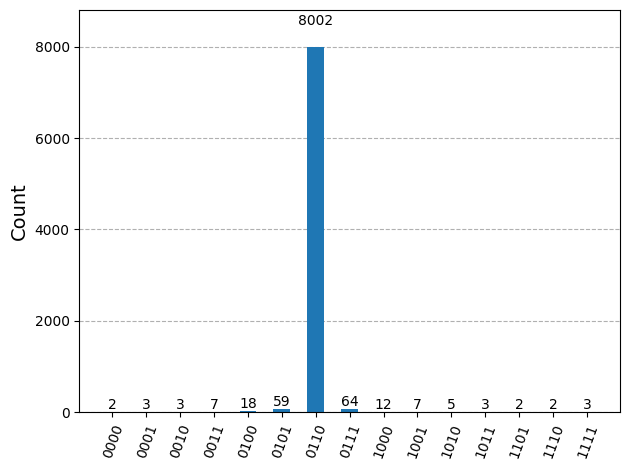

In [6]:
counts = simulate_circuit(qc)
plot_histogram(counts)

Now that I know the function works with 4 qubits, lets examine the differences between qubit register sizes in terms of accuracy and (rough) speed.

In [7]:
tSizes = 16 #the circuit will iterate through t = [3,tSizes]
theta_real = 0.37

def QPE(tSizes: int, theta_real: float, do_print: bool, do_graph: bool):
  results_data = []

  for t in range(3,tSizes+1):
    qc = build_qpe_circuit(t,theta_real)

    start = time.perf_counter()
    counts = simulate_circuit(qc)
    end = time.perf_counter()
    elapsed_time = end-start

    best_bitstring = max(counts, key=counts.get)
    best_count = counts[best_bitstring]
    prob = (best_count / shots)
    theta_est = bitstring_to_phase(best_bitstring,t)
    error = abs(theta_real-theta_est)

    #all results that fall within 2^-t of the real phase are considered a success
    successful_shots = 0

    for i in counts.keys():
      phase_estimate = bitstring_to_phase(i,t)
      real_error = abs(theta_real-phase_estimate)
      if real_error <= (2**-t):
        successful_shots += counts[i]

    p_success = successful_shots/shots

    results_data.append({
        "t": t,
        "bitstring": best_bitstring,
        "theta_est": theta_est,
        "error": error,
        "best_prob": prob,
        "success_prob": p_success,
        "raw_counts": counts,
        "time" : elapsed_time
    })

    if do_print: print(f"t = {t}, Phase Estimate: {theta_est:.5f}, Error: {error:.2g}, Time: {elapsed_time:.3g}s, Prob: {prob:.3g}")

  #graph
  if do_graph:
    errors = [entry["error"] for entry in results_data]

    plt.figure(figsize=(7, 4))
    plt.semilogy(range(3,tSizes+1), errors, marker="o", linestyle="--", color="crimson")
    plt.xlabel("Number of Counting Qubits")
    plt.ylabel("Estimation Error")
    plt.title(
        f"QPE Error Scaling for Non-Dyadic Phase $\\theta = {theta_real}$ (Log"
        " Scale)"
    )
    plt.grid(True, which="both", linestyle=":", alpha=0.6)
    plt.show()

  return results_data

## 3. Error Scaling: The Staircase

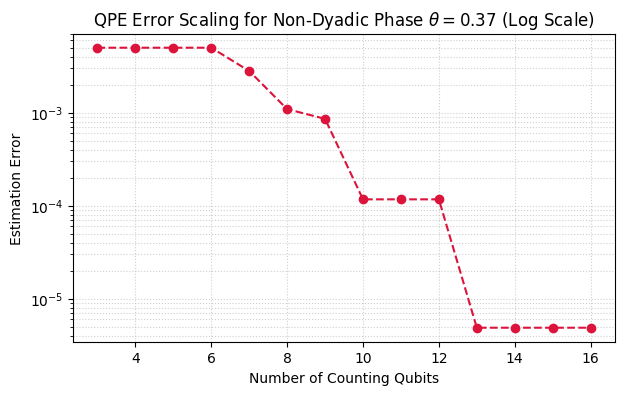

In [8]:
results_data = QPE(16,0.37,False,True)

### **Error Scaling**

**Plateaus**

*Why are there flat sections on the error scaling graph?*

The binary fraction for 0.37 is not exact, so every estimate is an approximation of the closest binary fraction to 0.37. This is a pretty fortunate test case for a small register size like $(t=3)$ because the best 3-bit approximation, $0.375$ or $3/8$, is also the best 4, 5, and 6-bit approximations because those fractions effectively add trailing zeros $(0.375=0.3750=0.37500)$ Since the fraction is not changing, the accuracy is not increased and the error does not change.

**Changing Slopes**

*Why do the slopes of improving accuracy vary?*

The reason that some slopes are greater than others (ex. 6 → 7 vs. 7 → 8) is due to "lucky" occurences. For a non-dyadic phase, the error is: $$Error = \frac{\vert{}\delta\vert{}}{2^t}$$ where $\delta=\vert2^t(0.37)-round(2^t×0.37)\vert$ and represents how close the estimation lands to a whole number. Since this error can range from 0 (lands directly on a whole number) and 0.5 (worst-case 50-50 split), the slope depends on the ratio of $\delta$ between consecutive errors.

**Contrast to $\theta = \frac{1}{3}$**

Below is the graph of the error scaling for $\theta = \frac{1}{3}$. Notice how the slope of the graph is a uniform line. This is because when 2 is raised to any power (modulo 3) it is only $\pm 1$ away from 0 (mod 3). According to the above equations, the error will always be $\frac{1}{3\times2^t}$, halving the error with each additional qubit.

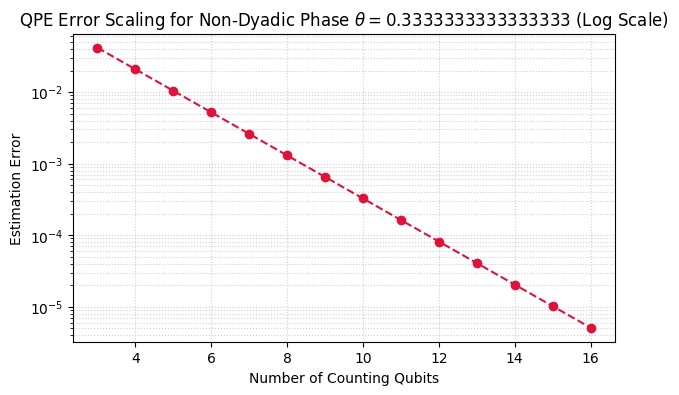

In [9]:
results_data = QPE(16,1/3,False,True)

## 4. Peak Resolution & The Nielsen-Chuang Bound

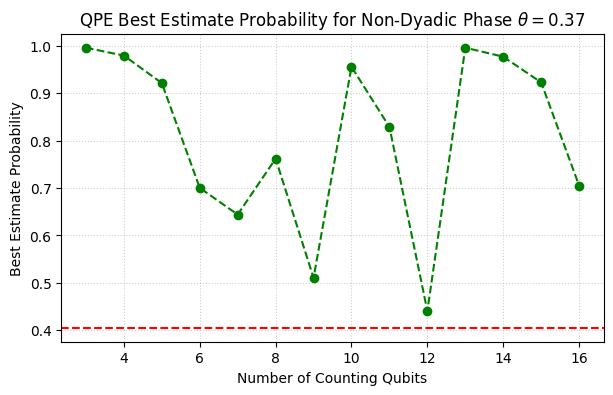

Phase offset for dominant mode: 0.000117
Phase offset for dominant mode: 0.000127


In [10]:
#graph probability of best estimate for each t
results_data = QPE(16,0.37,False,False)
probs = [entry["best_prob"] for entry in results_data]

plt.figure(figsize=(7, 4))
plt.plot(range(3,tSizes+1), probs, marker="o", linestyle="--", color="green")
plt.axhline(y=4 / (np.pi**2), color="r", linestyle="--", label="y = 4/pi^2")
plt.xlabel("Number of Counting Qubits")
plt.ylabel("Best Estimate Probability")
plt.title(
    f"QPE Best Estimate Probability for Non-Dyadic Phase $\\theta = {theta_real}$"
)
plt.grid(True, which="both", linestyle=":", alpha=0.6)
plt.show()


test_counts = {}
for i in results_data[9]["raw_counts"]:
  freq = results_data[9]["raw_counts"][i]
  ph = bitstring_to_phase(i,12)
  test_counts[ph] = freq
  if freq > 3000:
    print(f"Phase offset for dominant mode: {abs(ph - theta_real):.6f}")

### **Best Estimate Probability**
**Theoretical Bound**

*Why is there a red line at the bottom that is never crossed?*

That red line lies at ~0.405, which is known as the **Nielsen & Chuang lower bound**. Nielsen and Chuang found that the probability $P(b)$ of measuring the state $\vert b\rangle$, where $b$ is the closest integer to $2^t \theta$, is: $$P(b)\geq\frac{4}{\pi^2}\approx 0.405$$ Recall that $\delta = \vert 2^t\theta-round(2^t\theta)\vert$. As $\delta$ approaches the worst case value of 0.5, the probability of measuring the the closest state $\vert b\rangle$ leaks into a neighboring state $\vert b \pm 1 \rangle$. At $\delta=0.5$, both states will be at the minimum probability of 0.405 *(remember this for later!)*.

**Oscillations**

*Why does the best estimate probability oscillate?*

Similarly to what has been discussed earlier, the best estimate probabilty depends on $\delta$. If $\delta$ is close to zero, the best estimate the binary resolution allows is very close to the actual value of $\theta$ and most probability is concentrated around one number. In the event that $\delta$ is close to 0.5, the probability is spread between the best approximation and the runner-up, so the probability of the single best approximation is lowered.

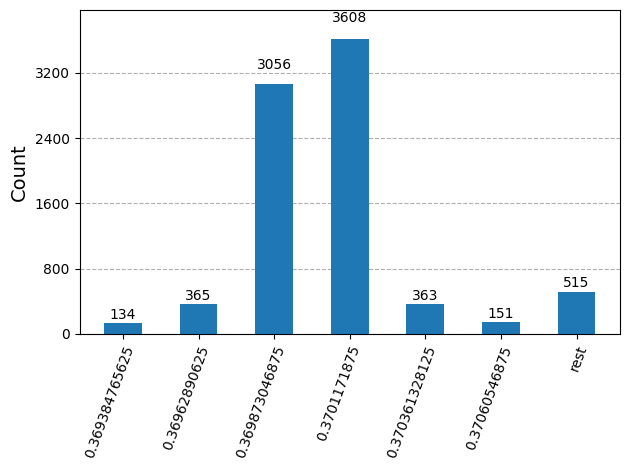

In [11]:
plot_histogram(test_counts,number_to_keep=6)

## 5. Success Probability & Window

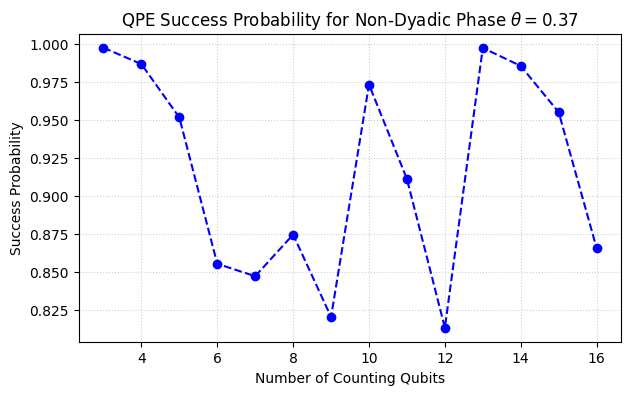

In [12]:
#graph probability of success (probability mass within 2^-t of real phase)
probs = [entry["success_prob"] for entry in results_data]

plt.figure(figsize=(7, 4))
plt.plot(range(3,tSizes+1), probs, marker="o", linestyle="--", color="blue")
plt.xlabel("Number of Counting Qubits")
plt.ylabel("Success Probability")
plt.title(
    f"QPE Success Probability for Non-Dyadic Phase $\\theta = {theta_real}$"
)
plt.grid(True, which="both", linestyle=":", alpha=0.6)
plt.show()

### **Success Probability**
**Success vs. Best**

*What is the difference between success probability and best estimate probability*

The condition for "success" in this algorithm can be stated as follows: $$\vert\theta_{estimate}-\theta_{real}\vert \leq 2^{-t}$$ This tests a two bin window to cover both the closest integer ($b$) and runner-up ($b \pm 1$). This greatly mitigates the problem of leakage into other bins, but not completely as can be seen in the matching shape of the graphs.

Both graphs follow the same shape because probability leakage into other bins further than $b \pm 1$ is also maximized as $\delta → 0.5$.

Going back to the last text block, the lower bound is also doubled as at the worst case scenario of $\delta =0.5$, the two closest bins combine their probabilities of ~0.405 to be ~0.81.